# Data Cleaning And EDA Of Flight Ticket Dataset

In [226]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


In [227]:
df = pd.read_excel('flight_price.xlsx')

In [228]:
df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [229]:
df.tail(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


**DESCRIPTION OF THE COLUMN**

Airline → Name of the flight operator (e.g., Air Asia, Vistara).

Date_of_Journey → The travel date.

Source → Departure city.

Destination → Arrival city.

Route → Path/airports covered (may include stopovers).

Dep_Time → Scheduled departure time.

Arrival_Time → Scheduled arrival time.

Duration → Total flight duration.

Total_Stops → Number of stops (non-stop, 1 stop, 2 stops, etc.).

Additional_Info → Extra details (e.g., meal info, baggage policy).

Price → Ticket cost.

In [230]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


**Observation**

***
count = 10683 → There are 10,683 flight price entries.

mean = 9087.06 → The average ticket price is about ₹9,087.

std = 4611.36 → Standard deviation (how spread out the prices are) is ~₹4,611, meaning prices vary a lot around the mean.

min = 1759 → The cheapest flight costs ₹1,759.

25% = 5277 → 25% of flights cost less than ₹5,277 (first quartile).

50% = 8372 → 50% of flights cost less than ₹8,372 (median).

75% = 12373 → 75% of flights cost less than ₹12,373 (third quartile).

max = 79512 → The most expensive flight is ₹79,512.

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [232]:
df.shape

(10683, 11)

In [233]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

<smalltext>The dataset has 10,683 rows and 11 columns. There are very few null values, with one in the ‘Route’ column and one in the ‘Total_Stops’ column.</smalltext>

# Data Cleaning
***

In [234]:
df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [235]:
## Date of Journey

df_copy=df.copy()

df_copy['Date_of_Journey'] = pd.to_datetime(df_copy['Date_of_Journey'],format='%d/%m/%Y')
df_copy['Journey_Date']= df_copy['Date_of_Journey'].dt.day
df_copy['Month_of_Journery']= df_copy['Date_of_Journey'].dt.month
df_copy['Year_of_Journery']= df_copy['Date_of_Journey'].dt.year
df_copy.head(2)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019


In [236]:
## dropping the date of journey column as we dont need that now becasue we have extracted day month and year from it for our analysis
df_copy.drop('Date_of_Journey',axis=1,inplace=True)
df_copy.head(2)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019


In [237]:
## seperating depature time into hours and minutes

df_copy['Dep_Hour']= df_copy['Dep_Time'].str.split(':').str[0] 
df_copy['Dep_Min']= df_copy['Dep_Time'].str.split(':').str[1] 

In [238]:
df_copy.head(2)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,05,50


In [239]:
## convertime dep_hour and dep_min into integer

df_copy['Dep_Hour']=df_copy['Dep_Hour'].astype(int) 
df_copy['Dep_Min']=df_copy['Dep_Min'].astype(int) 
df_copy[['Dep_Hour','Dep_Min']].dtypes


Dep_Hour    int32
Dep_Min     int32
dtype: object

In [240]:
## dropping the dep_time column as we dont need that now becasue we have extracted hours and minutes from it for our analysis
df_copy.drop('Dep_Time',axis=1,inplace=True)

In [241]:
df_copy.head(2)


,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50


In [242]:
## Droppping Route as it is not that much useful for our analysis
df_copy.drop('Route',axis=1,inplace=True)


In [243]:
df_copy.head(5)

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [244]:
## Seperating Arrival time into hours and minutes
df_copy['Arrival_Time'].unique()

array(['01:10 22 Mar', '13:15', '04:25 10 Jun', ..., '06:50 10 Mar',
       '00:05 19 Mar', '21:20 13 Mar'], dtype=object)

In [245]:
## Taking only hours and minutes from the arrival time column
df_copy['Arrival_Time']=df_copy['Arrival_Time'].astype(str).str.split(' ').str[0]

In [246]:
df_copy.head(5)

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,01:10,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,04:25,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [247]:
df_copy['Arrival_Time'].head(20).unique() 

array(['01:10', '13:15', '04:25', '23:30', '21:35', '11:25', '10:25',
       '05:05', '19:15', '23:00', '22:55', '13:55', '09:20', '19:50',
       '12:35'], dtype=object)

In [248]:
##seperating hour from arrival time
df_copy['Arrival_Hour']=df_copy['Arrival_Time'].str.split(':').str[0]

##seperating Minute from arrival time
df_copy['Arrival_Min']=df_copy['Arrival_Time'].str.split(':').str[1]



In [249]:
#dropping arrival time as we have extracted hours and minutes from it
df_copy.drop('Arrival_Time',axis=1,inplace=True)

df_copy.head(2)


,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,2h 50m,non-stop,No info,3897,24,3,2019,22,20,01,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15


In [250]:
##checking top 20 unique values in duration column
df_copy['Duration'].head(40).unique()

array(['2h 50m', '7h 25m', '19h', '5h 25m', '4h 45m', '2h 25m', '15h 30m',
       '21h 5m', '25h 30m', '7h 50m', '13h 15m', '2h 35m', '2h 15m',
       '12h 10m', '26h 35m', '4h 30m', '22h 35m', '23h', '20h 35m',
       '5h 10m', '15h 20m', '2h 55m', '13h 20m', '15h 10m', '5h 45m',
       '5h 55m', '13h 25m', '22h', '5h 30m', '10h 25m', '5h 15m',
       '2h 30m', '6h 15m', '11h 55m'], dtype=object)

In [251]:
##checking all unique values in duration column from last 20 rows
df_copy['Duration'].tail(20).unique()



array(['17h 5m', '2h 55m', '2h 30m', '24h 45m', '21h 25m', '7h 20m',
       '11h 15m', '17h 25m', '1h 20m', '19h 55m', '15h', '8h 40m',
       '2h 40m', '2h 35m', '3h', '8h 20m'], dtype=object)

In [252]:
## Extracting hours and minutes from duration column
df_copy['Duration_Hour']= df_copy['Duration'].str.split(' ').str[0]

## removing 'h' from duration hour column
df_copy['Duration_Hour']= df_copy['Duration_Hour'].str.replace('h',' ', case=False)

#Extracting minutes from duration column
df_copy['Duration_Min']= df_copy['Duration'].str.split(' ').str[1]
df_copy['Duration_Min']= df_copy['Duration_Min'].str.replace('m',' ', case=False)

In [253]:
## droping duration column as we have extracted hours and minutes from it
df_copy.drop('Duration',axis=1,inplace=True)


In [254]:
df_copy.head(5)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,2019,22,20,01,10,2,50
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,2019,9,25,04,25,19,NaN
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,2019,16,50,21,35,4,45


In [255]:
## rechecking datatypes for all columns
df_copy.dtypes

Airline              object
Source               object
Destination          object
Total_Stops          object
Additional_Info      object
Price                 int64
Journey_Date          int32
Month_of_Journery     int32
Year_of_Journery      int32
Dep_Hour              int32
Dep_Min               int32
Arrival_Hour         object
Arrival_Min          object
Duration_Hour        object
Duration_Min         object
dtype: object

In [256]:

df_copy['Arrival_Hour'].unique()

array(['01', '13', '04', '23', '21', '11', '10', '05', '19', '22', '09',
       '12', '06', '08', '03', '20', '16', '18', '15', '14', '00', '02',
       '07', '17'], dtype=object)

In [257]:
df_copy['Arrival_Hour']= df_copy['Arrival_Hour'].astype(int)


In [258]:
df_copy['Arrival_Hour'].unique()


array([ 1, 13,  4, 23, 21, 11, 10,  5, 19, 22,  9, 12,  6,  8,  3, 20, 16,
       18, 15, 14,  0,  2,  7, 17])

In [259]:
df_copy['Arrival_Hour']= df_copy['Arrival_Hour'].astype(int)


In [260]:
df_copy['Arrival_Min']= df_copy['Arrival_Min'].astype(int)


In [261]:
df_copy['Duration_Hour'].unique()

array(['2 ', '7 ', '19 ', '5 ', '4 ', '15 ', '21 ', '25 ', '13 ', '12 ',
       '26 ', '22 ', '23 ', '20 ', '10 ', '6 ', '11 ', '8 ', '16 ', '3 ',
       '27 ', '1 ', '14 ', '9 ', '18 ', '17 ', '24 ', '30 ', '28 ', '29 ',
       '37 ', '34 ', '38 ', '35 ', '36 ', '47 ', '33 ', '32 ', '31 ',
       '42 ', '39 ', '5m', '41 ', '40 '], dtype=object)

In [262]:
df_copy.loc[df_copy['Duration_Hour'] == '5m']


,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
6474,Air India,Mumbai,Hyderabad,2 stops,No info,17327,6,3,2019,16,50,16,55,5m,NaN


In [263]:
#droppping the row where duration hour is 5m as it is an outlier and cannot be converted to integer
df_copy.drop(index=6474,axis=0,inplace=True)

In [264]:
df_copy['Duration_Hour']=df_copy['Duration_Hour'].astype(int)


In [265]:
## filling missing values with 0 in duration minute column because if there is no minute value then it means it is 0 minutes
df_copy['Duration_Min'].fillna('0',inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_32124\3626095018.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Duration_Min'].fillna('0',inplace=True)


In [266]:
df_copy['Duration_Min'].isnull().sum()

0

In [267]:
df_copy['Duration_Min']=df_copy['Duration_Min'].astype(int)



In [268]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Airline            10682 non-null  object
 1   Source             10682 non-null  object
 2   Destination        10682 non-null  object
 3   Total_Stops        10681 non-null  object
 4   Additional_Info    10682 non-null  object
 5   Price              10682 non-null  int64 
 6   Journey_Date       10682 non-null  int32 
 7   Month_of_Journery  10682 non-null  int32 
 8   Year_of_Journery   10682 non-null  int32 
 9   Dep_Hour           10682 non-null  int32 
 10  Dep_Min            10682 non-null  int32 
 11  Arrival_Hour       10682 non-null  int32 
 12  Arrival_Min        10682 non-null  int32 
 13  Duration_Hour      10682 non-null  int32 
 14  Duration_Min       10682 non-null  int32 
dtypes: int32(9), int64(1), object(5)
memory usage: 959.7+ KB


In [269]:
df_copy.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25


In [270]:
## now for Total Stops column we will replace the non numerical values with numerical values
df_copy['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [271]:
#lets replace non-stop with 0 ,  1 stop with 1 , 2 stops with 2  and so on...

df_copy['Total_Stops']= df_copy['Total_Stops'].replace({
    'non-stop':0,
    '1 stop':1,
    '2 stops':2,
    '3 stops':3,
    '4 stops':4



})

C:\Users\user\AppData\Local\Temp\ipykernel_32124\2058465052.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['Total_Stops']= df_copy['Total_Stops'].replace({


In [272]:
df_copy['Total_Stops'].head(10)

0    0.0
1    2.0
2    2.0
3    1.0
4    1.0
5    0.0
6    1.0
7    1.0
8    1.0
9    1.0
Name: Total_Stops, dtype: float64

In [273]:
df_copy['Total_Stops'].isnull().sum()


1

In [274]:
# Option 1: assign back
df_copy['Total_Stops'] = df_copy['Total_Stops'].fillna(0)



In [275]:
df_copy['Total_Stops'] .head(10)

0    0.0
1    2.0
2    2.0
3    1.0
4    1.0
5    0.0
6    1.0
7    1.0
8    1.0
9    1.0
Name: Total_Stops, dtype: float64

In [276]:
df_copy['Total_Stops'].unique()

array([0., 2., 1., 3., 4.])

In [277]:
df_copy['Total_Stops']=df_copy['Total_Stops'].astype(int)


In [278]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Airline            10682 non-null  object
 1   Source             10682 non-null  object
 2   Destination        10682 non-null  object
 3   Total_Stops        10682 non-null  int32 
 4   Additional_Info    10682 non-null  object
 5   Price              10682 non-null  int64 
 6   Journey_Date       10682 non-null  int32 
 7   Month_of_Journery  10682 non-null  int32 
 8   Year_of_Journery   10682 non-null  int32 
 9   Dep_Hour           10682 non-null  int32 
 10  Dep_Min            10682 non-null  int32 
 11  Arrival_Hour       10682 non-null  int32 
 12  Arrival_Min        10682 non-null  int32 
 13  Duration_Hour      10682 non-null  int32 
 14  Duration_Min       10682 non-null  int32 
dtypes: int32(10), int64(1), object(4)
memory usage: 918.0+ KB


In [279]:
df_copy.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25


In [280]:
df_copy['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

# Exploratory Data Analysis


In [281]:
df_copy.head(10)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,16,50,21,35,4,45
5,SpiceJet,Kolkata,Banglore,0,No info,3873,24,6,2019,9,0,11,25,2,25
6,Jet Airways,Banglore,New Delhi,1,In-flight meal not included,11087,12,3,2019,18,55,10,25,15,30
7,Jet Airways,Banglore,New Delhi,1,No info,22270,1,3,2019,8,0,5,5,21,5
8,Jet Airways,Banglore,New Delhi,1,In-flight meal not included,11087,12,3,2019,8,55,10,25,25,30
9,Multiple carriers,Delhi,Cochin,1,No info,8625,27,5,2019,11,25,19,15,7,50


In [282]:
df_copy.isnull().sum()

Airline              0
Source               0
Destination          0
Total_Stops          0
Additional_Info      0
Price                0
Journey_Date         0
Month_of_Journery    0
Year_of_Journery     0
Dep_Hour             0
Dep_Min              0
Arrival_Hour         0
Arrival_Min          0
Duration_Hour        0
Duration_Min         0
dtype: int64

<p>There are no null values in any column.</p>

***

In [283]:
df_copy.shape

(10682, 15)

<p>Number of rows in dataset = 10682</p>
<p>Number of Columns in dataset = 15 </p>

***

In [284]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Airline            10682 non-null  object
 1   Source             10682 non-null  object
 2   Destination        10682 non-null  object
 3   Total_Stops        10682 non-null  int32 
 4   Additional_Info    10682 non-null  object
 5   Price              10682 non-null  int64 
 6   Journey_Date       10682 non-null  int32 
 7   Month_of_Journery  10682 non-null  int32 
 8   Year_of_Journery   10682 non-null  int32 
 9   Dep_Hour           10682 non-null  int32 
 10  Dep_Min            10682 non-null  int32 
 11  Arrival_Hour       10682 non-null  int32 
 12  Arrival_Min        10682 non-null  int32 
 13  Duration_Hour      10682 non-null  int32 
 14  Duration_Min       10682 non-null  int32 
dtypes: int32(10), int64(1), object(4)
memory usage: 918.0+ KB


In [285]:
Counter_int = len(df_copy.select_dtypes(include='int').columns)
Counter_object = len(df_copy.select_dtypes(include='object').columns) 
Counter_float = len(df_copy.select_dtypes(include='float').columns) 


print("Number of integer type columns:", Counter_int)
print("Number of object type columns:", Counter_object)
print("Number of float type columns:", Counter_float)


Number of integer type columns: 11
Number of object type columns: 4
Number of float type columns: 0


<p>Number of integer type columns: 11
<br>
Number of object type columns: 4
<br>
Number of float type columns: 0</p>

***

In [286]:
int_percent = len(df_copy.select_dtypes(include='int').columns)/len(df_copy.columns)*100
object_percent = len(df_copy.select_dtypes(include='object').columns)/len(df_copy.columns)*100

print(f"Percentage of integer type columns:{ int_percent}%")
print(f"Percentage of object type columns:{object_percent}%")



Percentage of integer type columns:73.33333333333333%
Percentage of object type columns:26.666666666666668%


<p>Percentage of integer type columns:73.33333333333333%
<br>
Percentage of object type columns:26.666666666666668%</p>

***

In [287]:
df_copy[['Price','Duration_Hour']].describe()

,Price,Duration_Hour
count,10682.000000,10682.000000
mean,9086.292735,10.247051
std,4610.885695,8.495234
min,1759.000000,1.000000
25%,5277.000000,2.000000
50%,8372.000000,8.000000
75%,12373.000000,15.000000
max,79512.000000,47.000000


**Observation**
<p> The average flight ticket price is Rs. 9086 and average flight duration is 10 hours </p>
<p> 50% of the flight ticket price is below 8372 and 50% of flight duration is below 8 hours</p>

***

In [288]:
df_copy.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25


In [289]:
df_copy['Month_of_Journery'].unique()

array([3, 5, 6, 4])

**#Count of Airline Company**

In [290]:
Airline_category= pd.DataFrame(df_copy['Airline'].value_counts())
Airline_category = Airline_category.reset_index()

Airline_category

,Airline,count
0,Jet Airways,3849
1,IndiGo,2053
2,Air India,1751
3,Multiple carriers,1196
4,SpiceJet,818
5,Vistara,479
6,Air Asia,319
7,GoAir,194
8,Multiple carriers Premium economy,13
9,Jet Airways Business,6


# Univariate analysis for categorical Columns

**#TOP 5 AIRLINE COMPANY**

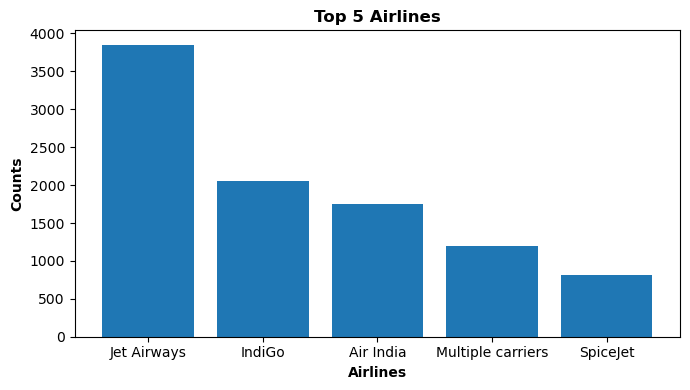

In [291]:
#tTOP 5 AIRLINE COMPANY

Top_5_Air_Lines= Airline_category.head(5)
plt.figure(figsize=(7,4))
plt.bar(Top_5_Air_Lines['Airline'], Top_5_Air_Lines['count'])
plt.title('Top 5 Airlines',fontweight='bold')
plt.xlabel('Airlines',fontweight='bold')
plt.ylabel('Counts',fontweight='bold')
plt.tight_layout()
plt.show()

**Observation**
<p> These are the Top 5 Airline company with highest number of flights </p>
<p> According to number of flights, Jet Airways comes at the first , indigo at second and Spicejet at last</p>

***

**# TOP 5 DESTINATION**

In [292]:
# TOP 5 DESTINATION
Destination= pd.DataFrame(df_copy['Destination'].value_counts())
Destination = Destination.reset_index()
Destination

,Destination,count
0,Cochin,4537
1,Banglore,2871
2,Delhi,1265
3,New Delhi,932
4,Hyderabad,696
5,Kolkata,381


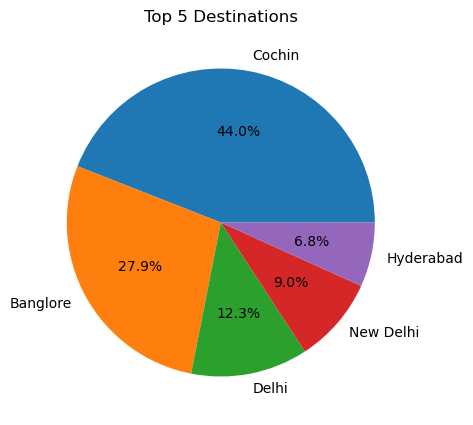

In [293]:
Top_5_Destinations= Destination.head(5)
plt.figure(figsize=(5,5))
plt.pie(Top_5_Destinations['count'], labels=Top_5_Destinations['Destination'],autopct='%1.1f%%')
plt.title('Top 5 Destinations')
plt.show()

**Observation**
<p> These are the Top Five Destinations made by flights</p>
<p> According to data, Cochin is the most visted one </p>

***


**COUNT OF ADDITIONAL INFORMATION ABOUT PASSENGER**

In [294]:
#COUNT OF ADDITIONAL INFORMATION ABOUT PASSENGER
df_copy['Additional_Info'].value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_32124\4006134534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy,y='Additional_Info', palette='Set2')


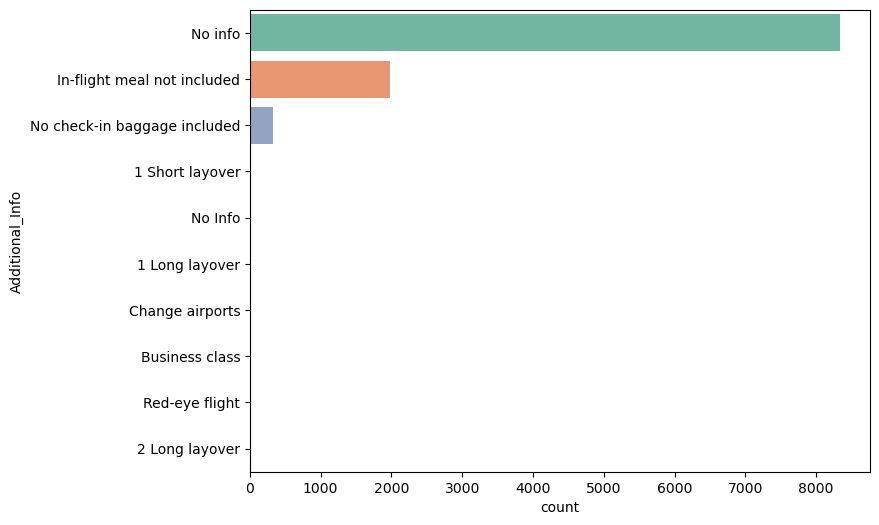

In [295]:
# PLOTTING COUNT OF ADDITIONAL INFORMATION ABOUT PASSENGER

plt.figure(figsize=(8,6))
sns.countplot(data=df_copy,y='Additional_Info', palette='Set2')
plt.show()

Most of the passenger preferd- **flight with meal not included**

Majority of the passenger didnt take much additional facilities in flight

***

**Comparision of different Airline with Price**

In [296]:
df_copy.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25


In [297]:
df_copy['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

**Calculating expensive airlines**

In [298]:
df_Average_Airline_Price= df_copy.groupby('Airline')['Price'].mean().reset_index()

In [299]:
df_Average_Airline_Price

,Airline,Price
0,Air Asia,5590.260188
1,Air India,9606.804112
2,GoAir,5861.056701
3,IndiGo,5673.682903
4,Jet Airways,11643.923357
5,Jet Airways Business,58358.666667
6,Multiple carriers,10902.678094
7,Multiple carriers Premium economy,11418.846154
8,SpiceJet,4338.284841
9,Trujet,4140.000000


In [300]:
df_Average_Airline_Price = df_Average_Airline_Price.sort_values(by='Price',ascending=False)
df_Average_Airline_Price 


,Airline,Price
5,Jet Airways Business,58358.666667
4,Jet Airways,11643.923357
7,Multiple carriers Premium economy,11418.846154
6,Multiple carriers,10902.678094
1,Air India,9606.804112
11,Vistara Premium economy,8962.333333
10,Vistara,7796.348643
2,GoAir,5861.056701
3,IndiGo,5673.682903
0,Air Asia,5590.260188


In [301]:
def ExpensiveFlight():
    plt.figure(figsize=(10,8))
    sns.barplot(data=df_Average_Airline_Price, x='Price',y='Airline')
    plt.title('FLIGHT RATES COMPARISION',fontweight='bold')
    plt.xlabel('PRICES',fontweight='bold')
    plt.ylabel('AIRLINE',fontweight='bold')
    plt.show()

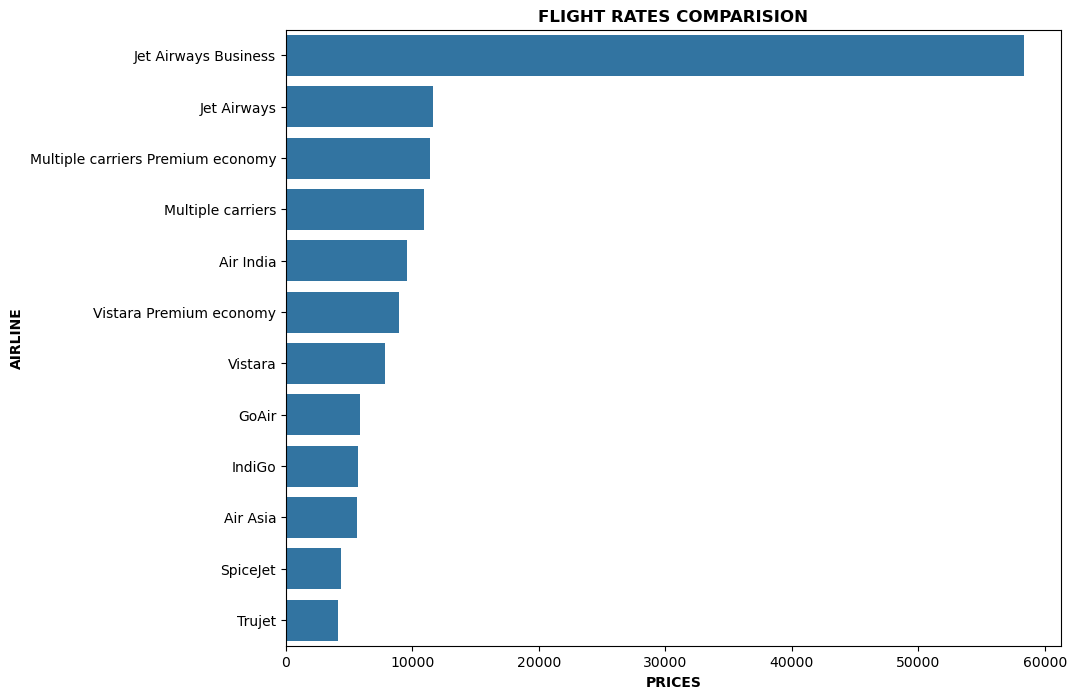

In [302]:
ExpensiveFlight()

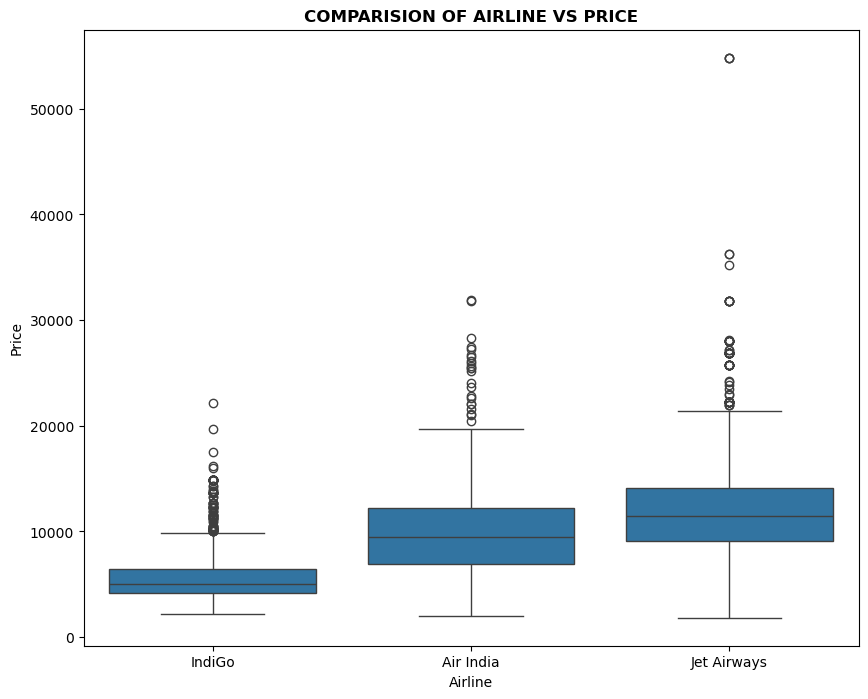

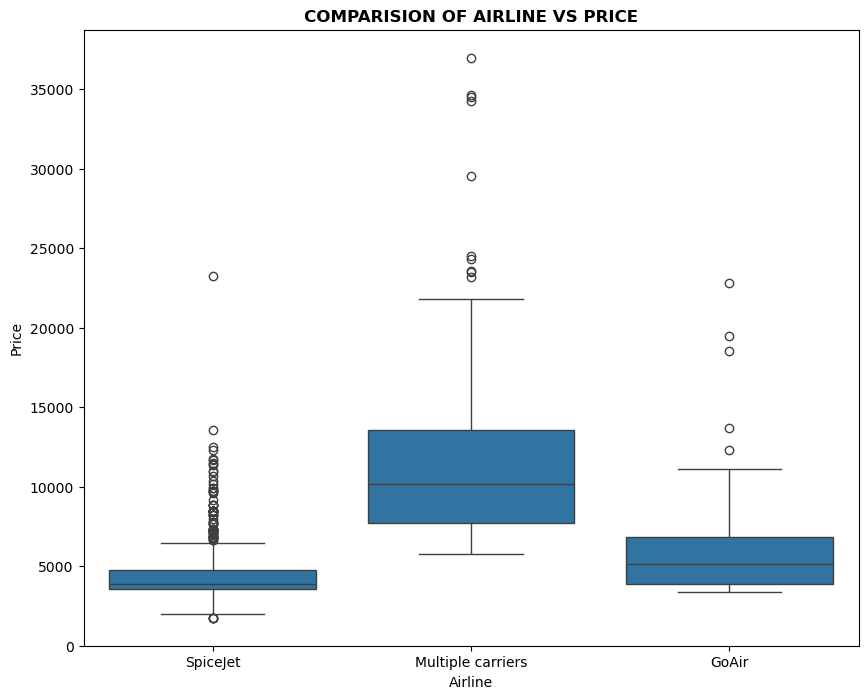

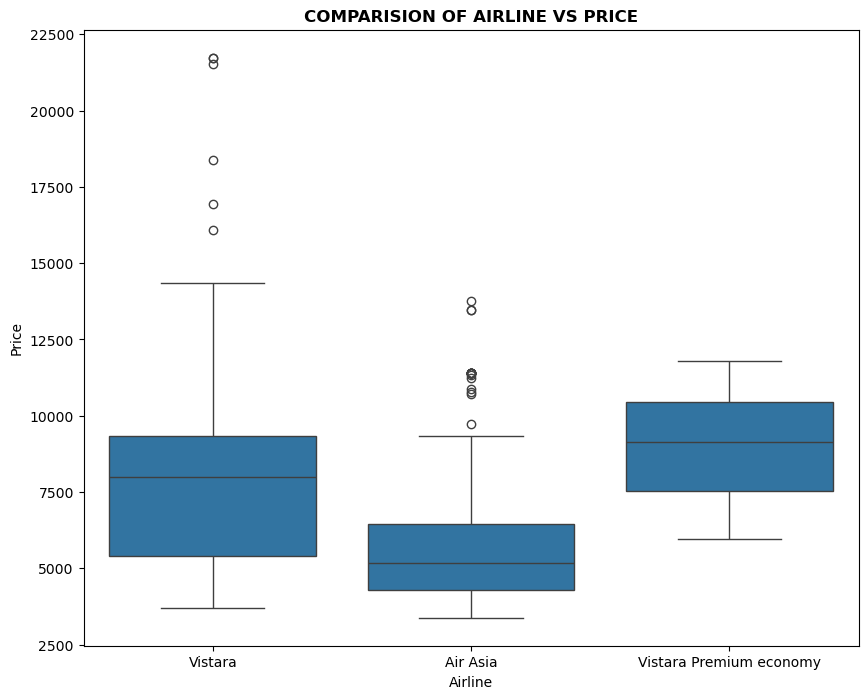

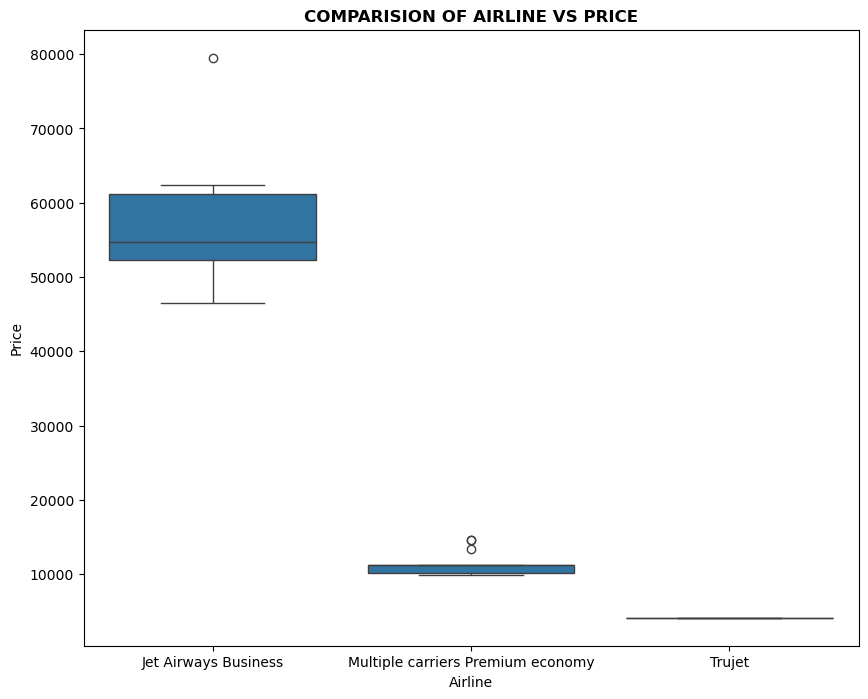

In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

group_size=3
airline=df_copy['Airline'].unique()

for i in range(0,len(airline),group_size):
    subset= airline[i:i+group_size]
    df_subset = df_copy[df_copy['Airline'].isin(subset)]
    
    plt.figure(figsize=(10,8))
    sns.boxplot(data=df_subset,x='Airline',y='Price')
    plt.title("COMPARISION OF AIRLINE VS PRICE",fontweight='bold')
    plt.show()




# Bivariate Analysis of Categorical Columns


**# Airline Vs  Destination**

In [304]:
# Airline Vs  Destination

ct=pd.crosstab(df_copy['Airline'],df_copy['Destination'])
ct

Destination,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
Airline,,,,,,
Air Asia,150,80,71,0,0,18
Air India,512,747,120,135,25,212
GoAir,25,76,69,0,0,24
IndiGo,445,705,366,196,184,157
Jet Airways,1256,1586,370,219,0,418
Jet Airways Business,0,2,0,0,0,4
Multiple carriers,0,1196,0,0,0,0
Multiple carriers Premium economy,0,13,0,0,0,0
SpiceJet,300,87,137,122,128,44


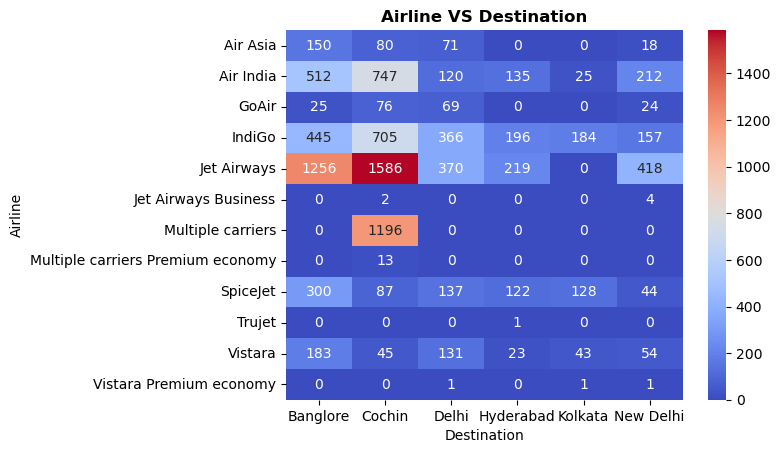

In [305]:
# Heat Map - Airline Vs  Destination

sns.heatmap(ct,annot=True,fmt='d',cmap='coolwarm')
plt.title('Airline VS Destination', fontweight='bold')
plt.show()


**Observation**

<p>Here, the number of flights taken by each airline to different destinations is shown.</p> <br>

**AirAsia** → 150 flights to **Bangalore**

**Cochin (most visited destination)** → majority of flights operated by **Jet Airways**

People visit **Banglore**  often from **Air Asia Flight**

***

**# Airline Vs  Source**

In [306]:
# Airline Vs  Source

ct=pd.crosstab(df['Airline'],df['Source'])
ct

Source,Banglore,Chennai,Delhi,Kolkata,Mumbai
Airline,,,,,
Air Asia,89,0,80,150,0
Air India,332,25,747,512,136
GoAir,93,0,76,25,0
IndiGo,523,184,705,445,196
Jet Airways,788,0,1586,1256,219
Jet Airways Business,4,0,2,0,0
Multiple carriers,0,0,1196,0,0
Multiple carriers Premium economy,0,0,13,0,0
SpiceJet,181,128,87,300,122


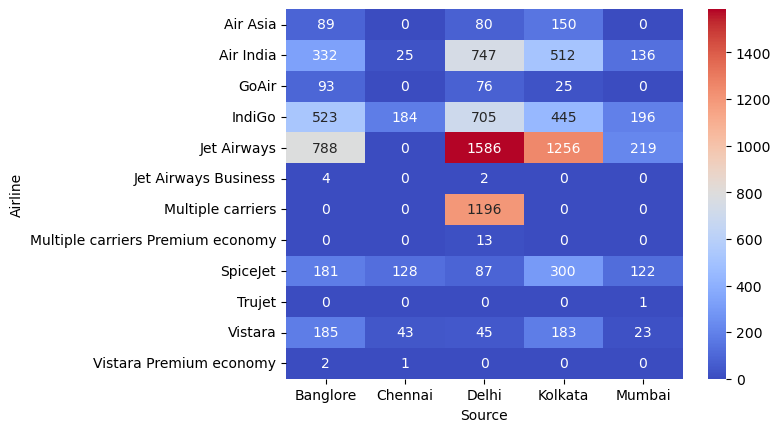

In [307]:

sns.heatmap(ct,annot=True,fmt='d',cmap='coolwarm')
plt.show()

**Observation**

**Relation among flights that are initially taken from origins to destinations.**

89 **AirAsia** flights took off from **Bangalore** and 150 **AirAsia** flights took off from **kolkata**.

**1586 (major)** **Jet Airways** flights took off from **Delhi**

***


# Bivariate analysis for Numerical Columns

In [308]:
df_copy.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25


**#Plane Stop Vs Price**

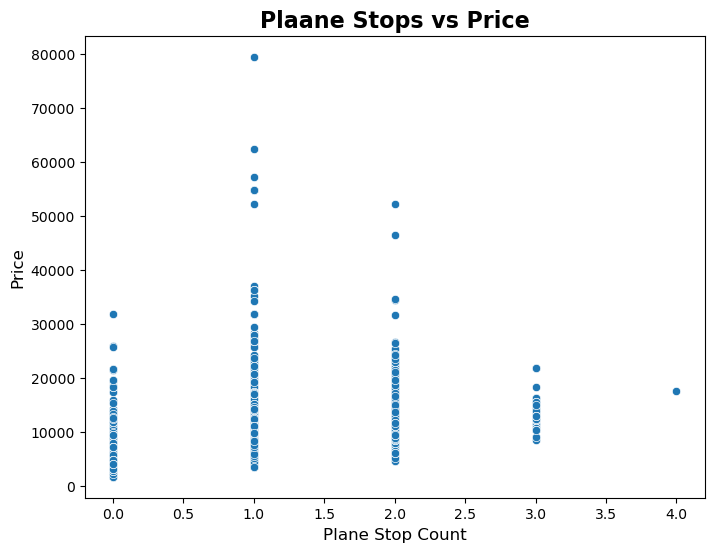

In [309]:
## Scatter Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_copy,x='Total_Stops',y='Price')
plt.title("Plaane Stops vs Price", fontsize=16, fontweight="bold")
plt.xlabel("Plane Stop Count", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

**#Flight Duration vs Price**

In [310]:
df_copy['Duration_Hour'].unique()

array([ 2,  7, 19,  5,  4, 15, 21, 25, 13, 12, 26, 22, 23, 20, 10,  6, 11,
        8, 16,  3, 27,  1, 14,  9, 18, 17, 24, 30, 28, 29, 37, 34, 38, 35,
       36, 47, 33, 32, 31, 42, 39, 41, 40])

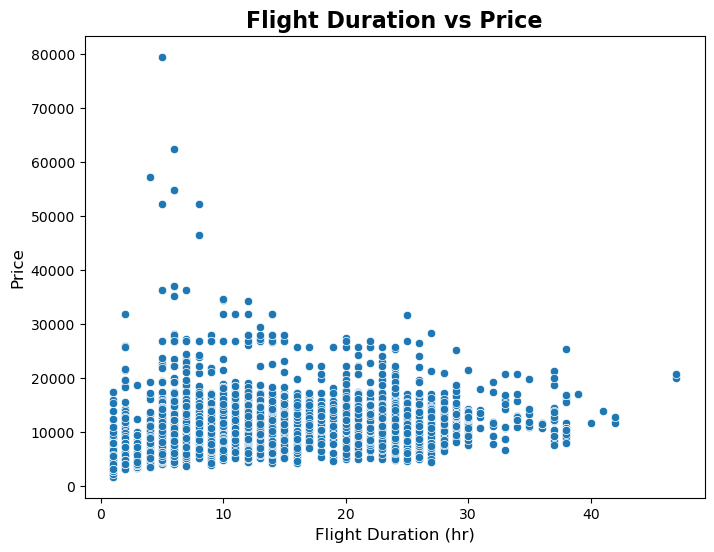

In [311]:
## Scatter Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_copy,x='Duration_Hour',y='Price')
plt.title("Flight Duration vs Price", fontsize=16, fontweight="bold")
plt.xlabel("Flight Duration (hr)", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

**#Depature Hour vs Price**

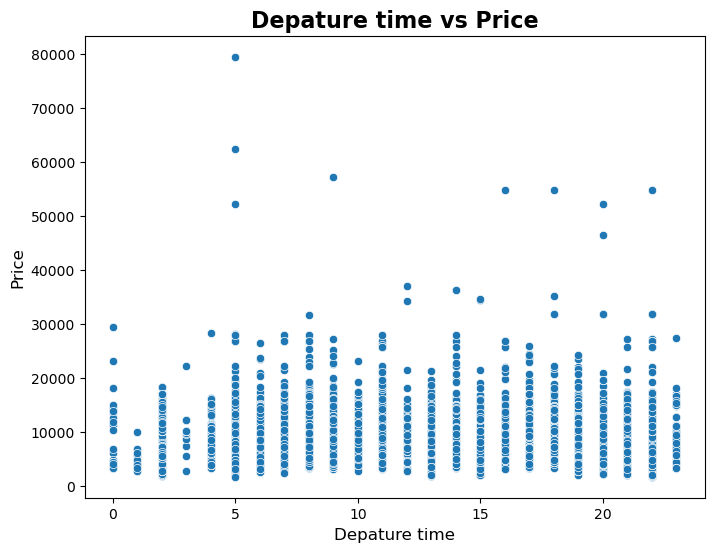

In [312]:
## Scatter Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_copy,x='Dep_Hour',y='Price')
plt.title("Depature time vs Price", fontsize=16, fontweight="bold")
plt.xlabel("Depature time", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

# Univariate analysis for Numerical Columns

**#Price Distribution**

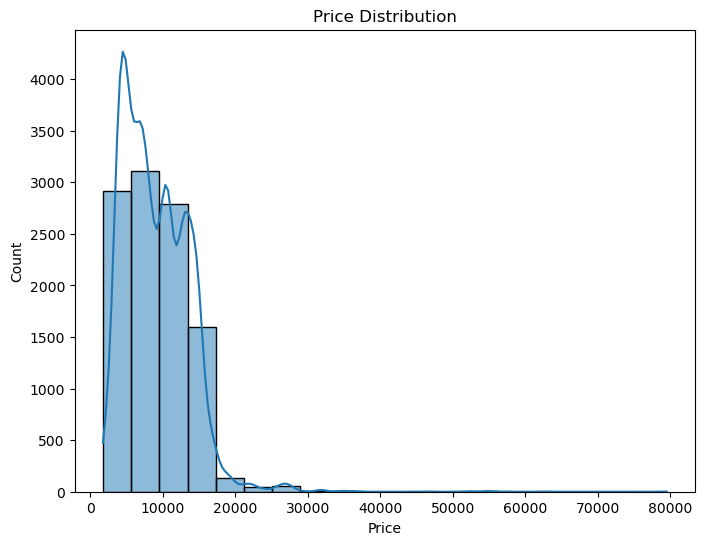

In [313]:
plt.figure(figsize=(8,6))
sns.histplot(df_copy['Price'],bins=20,kde=True)
plt.title('Price Distribution')
plt.show()

**#Box Plot of Price**

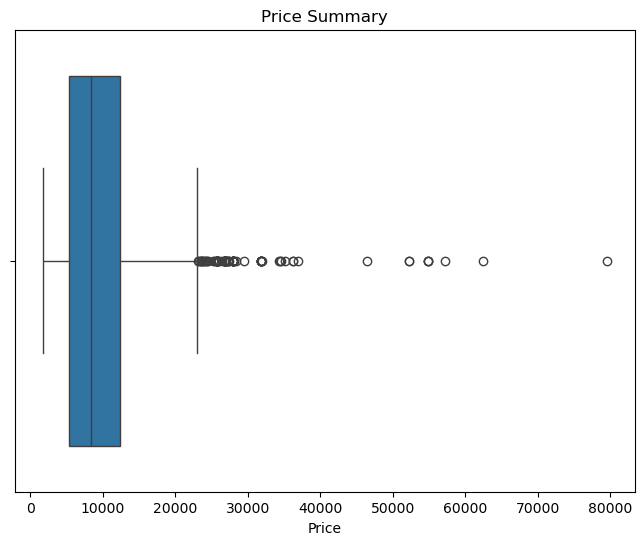

In [314]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df_copy['Price'])
plt.title('Price Summary')
plt.show()

**#Months VS Price**

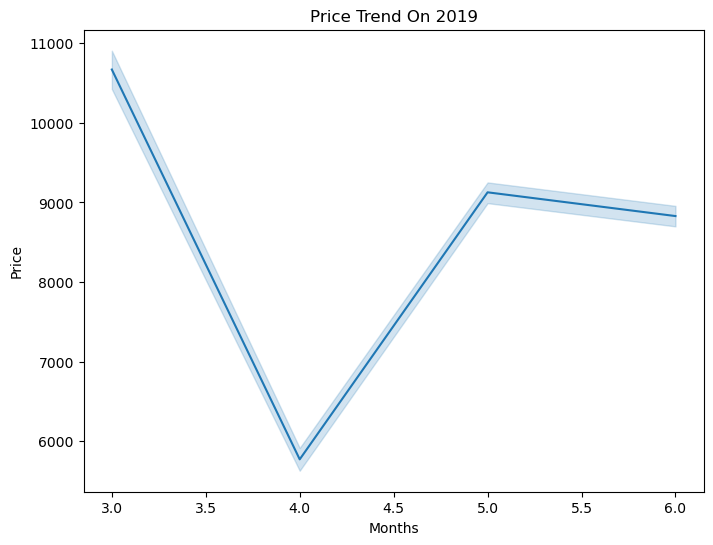

In [315]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df_copy, x='Month_of_Journery', y='Price')
plt.title('Price Trend On 2019')
plt.xlabel('Months')
plt.ylabel('Price')
plt.show()


In [316]:
df_copy.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,16,50,21,35,4,45


**#Total Stops Vs Price**

<Axes: xlabel='Total_Stops', ylabel='Price'>

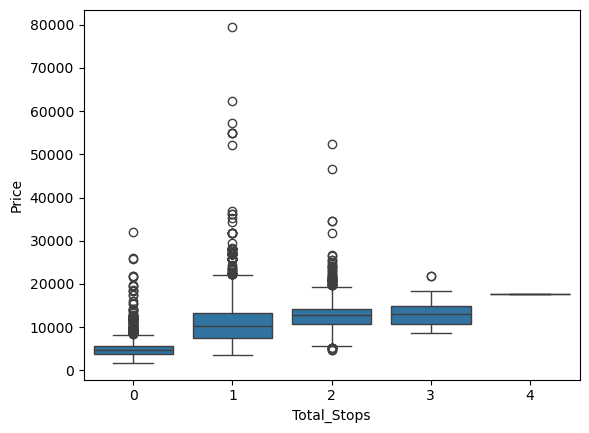

In [317]:
sns.boxplot(data=df_copy, x='Total_Stops', y='Price')


# FEATURE ENGINEERING


In [318]:
df_feature = df_copy.copy()

In [319]:
df_feature.head(5)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,16,50,21,35,4,45


## Encoding Airline Category

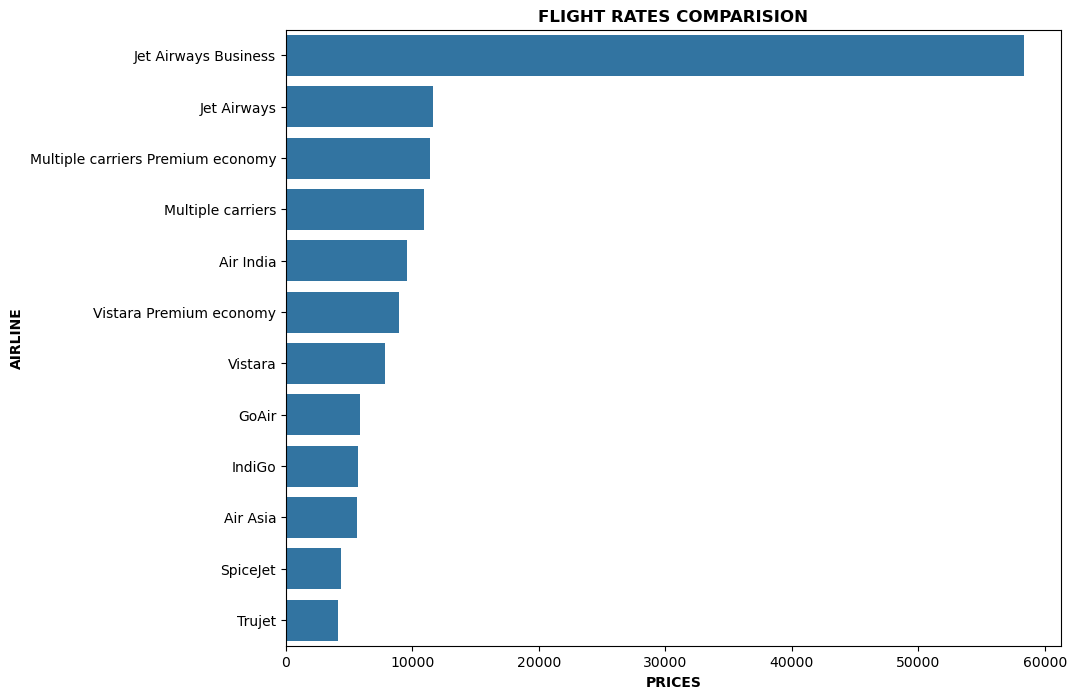

In [320]:
ExpensiveFlight()

Since Price have order according to different airline category,

i will be encoding Airline Category using Target Guided Encoding ( mean Encoding)

In [325]:
Average_Airline_Price_Dict = df_feature.groupby('Airline')['Price'].mean()

In [326]:
Average_Airline_Price_Dict = Average_Airline_Price_Dict.to_dict()

In [327]:
Average_Airline_Price_Dict

{'Air Asia': 5590.260188087775,
 'Air India': 9606.804111936037,
 'GoAir': 5861.056701030928,
 'IndiGo': 5673.68290306868,
 'Jet Airways': 11643.92335671603,
 'Jet Airways Business': 58358.666666666664,
 'Multiple carriers': 10902.678093645485,
 'Multiple carriers Premium economy': 11418.846153846154,
 'SpiceJet': 4338.284841075794,
 'Trujet': 4140.0,
 'Vistara': 7796.348643006263,
 'Vistara Premium economy': 8962.333333333334}

In [328]:
df_feature['Airline_encoded']= df_feature['Airline'].map(Average_Airline_Price_Dict)

In [329]:
df_feature

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min,Airline_encoded
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50,5673.682903
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25,9606.804112
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,9,25,4,25,19,0,11643.923357
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,18,5,23,30,5,25,5673.682903
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,16,50,21,35,4,45,5673.682903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,No info,4107,9,4,2019,19,55,22,25,2,30,5590.260188
10679,Air India,Kolkata,Banglore,0,No info,4145,27,4,2019,20,45,23,20,2,35,9606.804112
10680,Jet Airways,Banglore,Delhi,0,No info,7229,27,4,2019,8,20,11,20,3,0,11643.923357
10681,Vistara,Banglore,New Delhi,0,No info,12648,1,3,2019,11,30,14,10,2,40,7796.348643


In [ ]:
df_feature['Airline_encoded'].dtype

dtype('float64')

In [332]:
## dropppping airline category because we already converted that into numerical

df_feature.drop('Airline',axis=1,inplace=True)

In [355]:
df_feature.isnull().sum()

Source               0
Destination          0
Total_Stops          0
Additional_Info      0
Price                0
Journey_Date         0
Month_of_Journery    0
Year_of_Journery     0
Dep_Hour             0
Dep_Min              0
Arrival_Hour         0
Arrival_Min          0
Duration_Hour        0
Duration_Min         0
Airline_encoded      0
dtype: int64

In [334]:
df_feature.head()

,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,Duration_Min,Airline_encoded
0,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,1,10,2,50,5673.682903
1,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,13,15,7,25,9606.804112
2,Delhi,Cochin,2,No info,13882,9,6,2019,9,25,4,25,19,0,11643.923357
3,Kolkata,Banglore,1,No info,6218,12,5,2019,18,5,23,30,5,25,5673.682903
4,Banglore,New Delhi,1,No info,13302,1,3,2019,16,50,21,35,4,45,5673.682903


## ENCODING OTHER CATEGORRY

In [337]:
df_feature['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [338]:
## Sources and destination may not impact price like Airline does so doing One Hot Encoding 
## Also Target Guided Encoding may cause Overfitting

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [341]:
encoded = encoder.fit_transform(df_feature[['Source','Destination','Additional_Info']]).toarray()
encoded 

array([[1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.]])

In [342]:
df_encoded=pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

In [344]:
df_encoded.head()

,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [356]:
df_encoded.isnull().sum()

Source_Banglore                                 0
Source_Chennai                                  0
Source_Delhi                                    0
Source_Kolkata                                  0
Source_Mumbai                                   0
Destination_Banglore                            0
Destination_Cochin                              0
Destination_Delhi                               0
Destination_Hyderabad                           0
Destination_Kolkata                             0
Destination_New Delhi                           0
Additional_Info_1 Long layover                  0
Additional_Info_1 Short layover                 0
Additional_Info_2 Long layover                  0
Additional_Info_Business class                  0
Additional_Info_Change airports                 0
Additional_Info_In-flight meal not included     0
Additional_Info_No Info                         0
Additional_Info_No check-in baggage included    0
Additional_Info_No info                         0


In [357]:
df_feature = df_feature.reset_index(drop=True)
df_encoded = df_encoded.reset_index(drop=True)

Encoded_df_final = pd.concat([df_feature, df_encoded], axis=1)


In [358]:
Encoded_df_final.drop(['Source','Destination','Additional_Info'], axis=1, inplace=True)

In [359]:
Encoded_df_final.head(5)

,Total_Stops,Price,Journey_Date,Month_of_Journery,Year_of_Journery,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hour,...,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0,3897,24,3,2019,22,20,1,10,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,7662,1,5,2019,5,50,13,15,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,13882,9,6,2019,9,25,4,25,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,6218,12,5,2019,18,5,23,30,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,13302,1,3,2019,16,50,21,35,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [360]:
Encoded_df_final.isnull().sum()

Total_Stops                                     0
Price                                           0
Journey_Date                                    0
Month_of_Journery                               0
Year_of_Journery                                0
Dep_Hour                                        0
Dep_Min                                         0
Arrival_Hour                                    0
Arrival_Min                                     0
Duration_Hour                                   0
Duration_Min                                    0
Airline_encoded                                 0
Source_Banglore                                 0
Source_Chennai                                  0
Source_Delhi                                    0
Source_Kolkata                                  0
Source_Mumbai                                   0
Destination_Banglore                            0
Destination_Cochin                              0
Destination_Delhi                               0


In [362]:
Encoded_df_final.shape

(10682, 33)

In [365]:


df_copy.to_csv('Updated_Dataset/Aryan_Dangol_Flight_Ticket_Cleaned_Data',index=False)

In [368]:
Encoded_df_final.to_csv('Updated_Dataset/Aryan_Dangol_Flight_Ticket_Feature_Engineering',index=False)
